In [1]:
from typing import NamedTuple
import warnings

import matplotlib.pyplot as plt
import mlflow
from mlflow.models import infer_signature
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, recall_score, precision_score
from sklearn.metrics import f1_score, classification_report, roc_curve
from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.neural_network._multilayer_perceptron import ConvergenceWarning


warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Обучение модели

## Загрузим датасет

In [2]:
data = pd.read_csv("GoT_preprocessed_data.csv", index_col="S.No")
target = pd.read_csv("GoT_target.csv", index_col="S.No")

assert (data.shape[0] == 1557 and target.shape[0] == 1557), "Размер датасета не соотв. исходному"

### Выделим целевую переменную

In [3]:
X = data
y = target.to_numpy().flatten()

### Разделим выборку

In [4]:
# 70% - трейн, 15% - валидация, 15% - тест
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.7, random_state=42)  # 70% - трейн, 30% - валидация+тест
X_val, X_test, y_val, y_test = train_test_split(X_val, y_val, test_size=0.5, random_state=42)  # 15% - валидация, 15% - тест

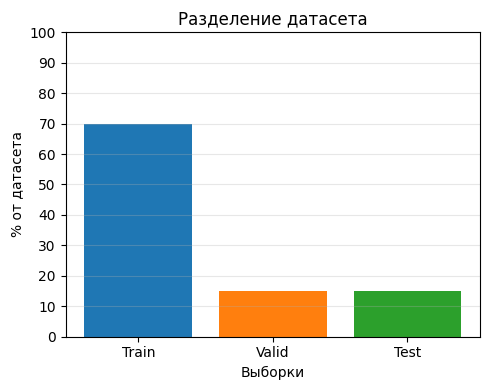

In [5]:
viz = pd.Series({
    'Train': 70,
    'Valid': 15,
    'Test': 15
})

plt.figure(figsize=(5, 4))
plt.bar(viz.index, viz.values, color=['tab:blue', 'tab:orange', 'tab:green'])
plt.title('Разделение датасета')
plt.xlabel('Выборки')
plt.yticks([i for i in range(0, 101, 10)])
plt.ylabel('% от датасета')
plt.grid(axis='y', alpha=0.3)

plt.ylim(0, 100)

plt.tight_layout()
plt.savefig("dataset_split.jpg", bbox_inches='tight', dpi=150)
plt.show()

Валидационную выборку будем использовать для расчёта метрик на этапе выбора модели,   
на тестовой выборке будем расчитывать итоговые метрики самой лучшей модели.

## Инициализируем модели

In [6]:
mlp_param_grid = (
    {
        'activation' : ['relu'],
        'solver' : ['adam'],
        'hidden_layer_sizes': [
            (100,), (13,), (13, 1), (13, 13, 1), (20,), (3,), (5,)
        ],
        'max_iter': [100, 600, 2000, 10000],
        'random_state': [1337]
    }
)

In [7]:
models = {
    'Naive Bayes': GaussianNB(),
    'Random Forest (Estim=5)': RandomForestClassifier(5, random_state=1337),
    'Random Forest (Estim=10)': RandomForestClassifier(10, random_state=1337),
    'Random Forest (Estim=20)': RandomForestClassifier(20, random_state=1337),
    'Random Forest (Estim=50)': RandomForestClassifier(50, random_state=1337),
    'Logistic Regression (L1)': LogisticRegression(l1_ratio=1, solver='liblinear'),
    'Logistic Regression (L2)': LogisticRegression(l1_ratio=0),
    'Support Vector (C=0.5)': SVC(C=0.5),
    'Support Vector (C=1.0)': SVC(C=1.0),
    'Support Vector (C=2.0)': SVC(C=2.0),
}

metrics = ('Accuracy', 'Recall', 'Precision', 'F1', 'ROC-AUC')

In [8]:
def calc_metrics(y_val, y_pred) -> dict[str, float]:
    accuracy = accuracy_score(y_val, y_pred)
    recall = recall_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred)
    f1_metric = f1_score(y_val, y_pred)
    roc_auc = roc_auc_score(y_val, y_pred, average=None)

    return {
        'accuracy': round(accuracy, 5),
        'recall': round(recall, 5),
        'precision': round(precision, 5),
        'f1': round(f1_metric, 5),
        'roc_auc': round(roc_auc, 5)
    }

In [10]:
mlflow.set_experiment("Game of Thrones Deaths")
with mlflow.start_run():
    clf = GridSearchCV(MLPClassifier(), mlp_param_grid, cv=3, scoring='roc_auc')
    results = pd.DataFrame(index=list(models.keys()), columns=metrics)

    clf.fit(X, y)
    
    best_model = clf.best_estimator_
    y_pred = best_model.predict(X_val)
    model_metrics = calc_metrics(y_val, y_pred)

    mlflow.log_param('N_estimators', best_model.n_estimators or None)
    mlflow.log_param('penalty', best_model.penalty or None)
    mlflow.log_param('C', best_model.C or None)

    mlflow.log_metrics(model_metrics)

    y_test = best_model.predict(X_test)
    signature = infer_signature(X_test, y_test)
    mlflow.sklearn.log_model(best_model, "model", signature=signature)
    

KeyboardInterrupt: 

In [ ]:
models_rating = results.sort_values('ROC-AUC', ascending=False)
models_rating

In [ ]:
best_model_name = models_rating.iloc[0].name
best_model = models[best_model_name]
print(best_model)

y_pred = best_model.predict(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred)

plt.figure(figsize=(5.5, 5))
plt.plot(fpr * 100, tpr * 100)
plt.xlabel('False Positive Rate, %')
plt.ylabel('True Positive Rate, %')
plt.title(f'ROC Curve (AUC = {round(roc_auc, 2)})')
plt.grid(alpha=0.3)
plt.xlim(-1, 101)
plt.ylim(-1, 101)

plt.savefig("best_model_roc_curve.jpg", bbox_inches='tight', dpi=200)
plt.show()